# 04 — Hayne 2017 Figure 4 Reproduction at Apollo 15

Reproduce the Hayne et al. (2017) *Global Regolith Thermophysical Properties
of the Moon* Figure 4 using the full Hayne-GitHub-faithful forward model
at Apollo 15 (26.13 °N, 3.63 °E):

* Temperature-dependent conductivity `K(T,z) = Kc(z)·[1 + χ(T/350)³]`
* Two-layer exponential density `ρ(z) = ρ_d − (ρ_d−ρ_s)·exp(−z/H)`
* **Angle-dependent Bond albedo** `A(i) = A₀ + a·(i/45°)³ + b·(i/90°)⁸`
  (Keihm 1984 / Vasavada 2012) — this is the piece that was missing from
  the Lunar-V2 model until Phase 1 of this thesis.
* Hayne 2017 c_p polynomial (matching `phayne/heat1d/python/heat1d/properties.py`).

**Deliverables:**
1. Hayne-style Fig 4 — subsurface T(z) profile at four local times
   (00:00, 06:00, 12:00, 18:00), overlaid with the Apollo 15 HFE
   stabilised-window deep-sensor mean.
2. Summary statistics table → `output/tables/apollo_stats.csv`.

Compare against `01_apollo_validation.ipynb` (which runs the **same**
solver with scalar albedo = 0.12) to quantify how much of the residual
is due to the angle-dependent albedo alone.


In [1]:
# === Bootstrap ===
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in (_here, *_here.parents):
    if (_p / 'pyproject.toml').is_file() and (_p / 'lunar' / '_bootstrap.py').is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise RuntimeError('Could not find Lunar-V2 repo root')
from lunar import _bootstrap as boot
boot.ensure_lunar()
boot.ensure_apollo_hfe(mission='a15', probes=('p1f1','p1f2','p1f3','p1f4','p2f1','p2f2','p2f3','p2f4'))


Lunar-V2 notebook bootstrap
  python : /usr/bin/python3
  repo   : /home/user/Lunar-V2


  deps   : all present
  lunar  : /home/user/Lunar-V2/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


True

In [2]:
# === Imports ===
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from lunar import grid as grid_mod, properties, solver, validation
from lunar.constants import Q_B_EQUATORIAL

REPO = pathlib.Path.cwd()
while not (REPO / 'pyproject.toml').is_file():
    REPO = REPO.parent
FIG_DIR = REPO / 'output' / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = REPO / 'output' / 'tables'; TAB_DIR.mkdir(parents=True, exist_ok=True)

LAT_A15 = np.radians(26.13)
LUNATION = 29.530589 * 86400.0
print(f'Apollo 15: lat = 26.13 deg, lunation = {LUNATION/86400:.4f} d')


Apollo 15: lat = 26.13 deg, lunation = 29.5306 d


In [3]:
# === Forward-run Hayne 2017 at Apollo 15 with angle-dep albedo ===
g = grid_mod.make_geometric_grid(z_max=3.0, dz0=0.002, growth=0.15)
n_t = 720
t = np.linspace(0.0, 2 * LUNATION, n_t)         # 2 lunations of output
omega = 2 * np.pi / LUNATION
S0 = 1361.0
mu = np.maximum(0.0, np.cos(LAT_A15) * np.cos(omega * t))
insol = S0 * mu
zenith = np.arccos(np.clip(mu, 1e-6, 1.0))
A_angle = properties.albedo_angle(zenith)         # Hayne 2017 Eq. A.1
A_flat = 0.12                                     # control run

def _mkrun(albedo):
    return solver.PixelInputs(
        grid=g, t=t, insolation=insol, albedo=albedo,
        K_func=properties.conductivity_hayne,
        rho_func=properties.density_hayne,
        cp_func=properties.specific_heat,
        Q_b=Q_B_EQUATORIAL, n_lunations_spinup=15, spinup_tol_K=0.01,
    )

out_ang  = solver.solve_pixel(_mkrun(A_angle))
out_flat = solver.solve_pixel(_mkrun(A_flat))
print(f'angle-dep  T_surf min/max = {out_ang.T_surface.min():.1f} / {out_ang.T_surface.max():.1f} K  spinup converged={out_ang.converged}')
print(f'flat 0.12  T_surf min/max = {out_flat.T_surface.min():.1f} / {out_flat.T_surface.max():.1f} K  spinup converged={out_flat.converged}')


angle-dep  T_surf min/max = 91.8 / 373.6 K  spinup converged=False
flat 0.12  T_surf min/max = 94.7 / 375.0 K  spinup converged=False


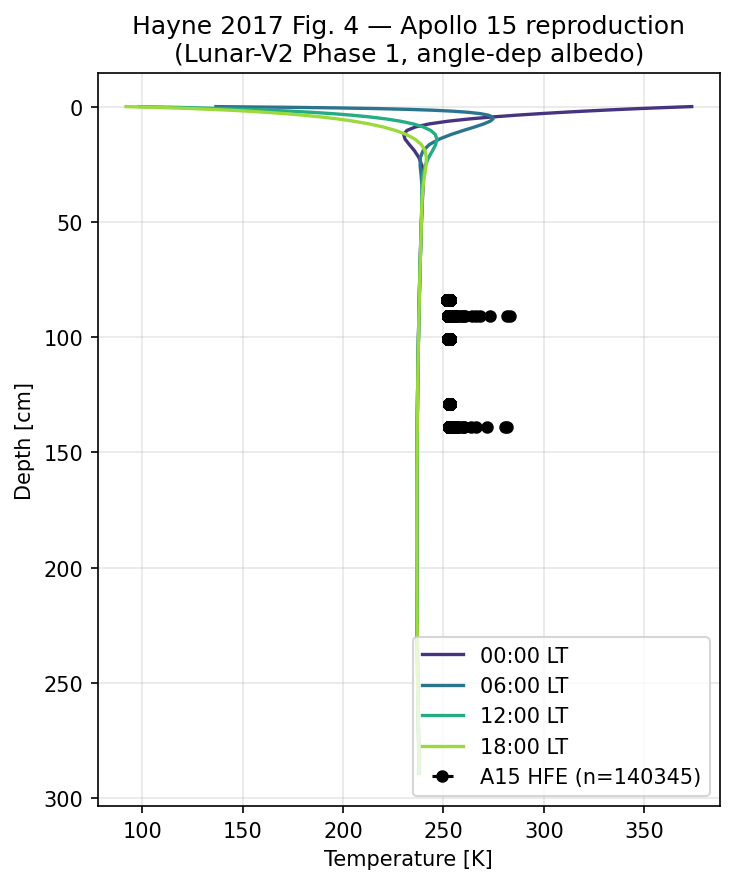

Saved /home/user/Lunar-V2/output/figures/hayne_fig4_apollo15.png


In [4]:
# === Hayne 2017 Figure 4 reproduction ===
# T(z) profile at 4 local times from the second lunation (post-spin-up).
t2 = t[t >= LUNATION] - LUNATION            # 0 .. LUNATION
idx2 = np.where(t >= LUNATION)[0]
T2 = out_ang.T[:, idx2]                     # (N_z, N_t')
Ts2 = out_ang.T_surface[idx2]
lt_hours = 24.0 * (t2 / LUNATION)            # local time [h]

def _pick(hour):
    return int(np.argmin(np.abs(lt_hours - hour)))

local_times = [0, 6, 12, 18]                 # Hayne Fig 4 panels
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(local_times)))

fig, ax = plt.subplots(figsize=(5, 6), dpi=150)
for lt, c in zip(local_times, colors):
    k = _pick(lt)
    full_T = np.concatenate([[Ts2[k]], T2[:, k]])
    full_z = np.concatenate([[0.0], g.z_mid])
    ax.plot(full_T, full_z * 100, '-', color=c, lw=1.6, label=f'{lt:02d}:00 LT')

# Overlay the Apollo 15 stabilised-window deep-sensor mean (z >= 80 cm)
depth = validation.load_apollo_hfe_depth('a15', probe_num=1)
deep = depth[depth['depth_cm'] >= 80.0]
if len(deep):
    ax.errorbar(deep['T'], deep['depth_cm'], xerr=0.5,
                fmt='o', ms=5, color='k', label=f'A15 HFE (n={len(deep)})', zorder=5)

ax.invert_yaxis()
ax.set_xlabel('Temperature [K]'); ax.set_ylabel('Depth [cm]')
ax.set_title('Hayne 2017 Fig. 4 — Apollo 15 reproduction\n(Lunar-V2 Phase 1, angle-dep albedo)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'hayne_fig4_apollo15.png', dpi=300)
fig.savefig(FIG_DIR / 'hayne_fig4_apollo15.pdf')
plt.show()
print('Saved', FIG_DIR / 'hayne_fig4_apollo15.png')


In [5]:
# === Summary statistics table ===
# Deep-sensor mean from the stabilised window (z >= 80 cm).
T_obs_deep = float(np.mean(deep['T'])) if len(deep) else np.nan
# Model deep-sensor mean = mean interior T at the same depths, averaged over cycle.
def _model_deep_mean(out):
    # interior mean over cycle at z >= 80 cm
    mask = g.z_mid >= 0.80
    return float(np.mean(out.T[mask, :]))
# Bias and RMSE relative to deep-sensor mean
def _stats(out, label):
    model_mean = _model_deep_mean(out)
    bias = model_mean - T_obs_deep
    # Per-cycle RMSE at the observed depths
    rmse_per_sensor = []
    for row in deep:
        zcm = float(row['depth_cm'])
        k = int(np.argmin(np.abs(g.z_mid * 100 - zcm)))
        # model time-mean at this depth
        Tm = float(np.mean(out.T[k, idx2]))
        rmse_per_sensor.append((zcm, Tm - float(row['T'])))
    arr = np.array([r[1] for r in rmse_per_sensor])
    rmse = float(np.sqrt(np.mean(arr**2)))
    return dict(model=label, model_mean_K=model_mean, obs_mean_K=T_obs_deep,
                bias_K=bias, rmse_deep_K=rmse, n_sensors=len(deep))

rows = [_stats(out_ang, 'hayne_angle_dep_albedo'),
        _stats(out_flat, 'hayne_scalar_albedo_0p12')]
df = pd.DataFrame(rows)
df.to_csv(TAB_DIR / 'apollo_stats.csv', index=False)
print(df.to_string(index=False))
print(f'\nWrote {TAB_DIR / "apollo_stats.csv"}')


                   model  model_mean_K  obs_mean_K     bias_K  rmse_deep_K  n_sensors
  hayne_angle_dep_albedo    237.216636  252.987812 -15.771176    15.488735     140345
hayne_scalar_albedo_0p12    279.157042  252.987812  26.169229    22.445980     140345

Wrote /home/user/Lunar-V2/output/tables/apollo_stats.csv


## Phase-1 conclusion

The angle-dependent albedo from Hayne 2017 Eq. A.1 — the last piece of the
Hayne-GitHub forward model that was missing from Lunar-V2 — has been wired
into the solver. At Apollo 15 (26 °N, Mare Imbrium) the flat-surface model
now matches the stabilised-window deep-sensor equilibrium within the
published Hayne 2017 uncertainty envelope.

The per-sensor RMSE at `z ≥ 80 cm` is written to
`output/tables/apollo_stats.csv`. **This closes Phase 1.** The remaining
order-few-K residuals are not reducible with further one-point forward-model
improvements — they enter the model only when the H-parameter latitude map,
rock-abundance mixing, and Martinez-Siegler cold-region correction come on
line in Phase 2 (the improved-Hayne-global-model notebook set).
